# Time/Domain Detector Probe (CustomCNN variants)

Goal: stress-test the dataset/model for leakage by proving the CustomCNN behaves like a "time detector" rather than a damage detector.

We now train three CustomTimeDetector variants: (1) baseline on the raw data, (2) a pixel-shuffled/distorted control, and (3) an intact model on the resampled dataset. The runs are compared via metrics, learning curves, and Grad-CAMs (distorted + resampled) to see whether spatial resampling reduces the time-detector failure mode.

Experiments:
1) **Intact post-event test**: feed an intact post-hurricane tile; a time detector will still predict damage.
2) **Shuffle control**: train a pixel-shuffled variant; if accuracy stays high, the model is using global color stats only.
3) **Resampled dataset**: train on the spatially resampled splits without destructive augmentations.
4) **Grad-CAM**: visualize focus across models; a time detector yields diffuse/background heatmaps.


In [5]:

from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from matplotlib.ticker import MaxNLocator
from PIL import Image

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})


here = Path.cwd().resolve()
for candidate in [here] + list(here.parents):
    src_dir = candidate / "src"
    if src_dir.exists():
        src_str = str(src_dir)
        if src_str not in sys.path:
            sys.path.insert(0, src_str)
        break

from utils import resolve_project_root

PROJECT_ROOT = resolve_project_root()
project_src = PROJECT_ROOT / "src"
if str(project_src) not in sys.path:
    sys.path.insert(0, str(project_src))


from config import TrainConfig
from data.datamodule import DataModule
from data.transforms import build_transforms
from models import build_model
from models.custom_time_detector import CustomTimeDetector, PixelShuffleDestroyer
from training.trainer import Trainer


In [6]:
DATA_ROOT = PROJECT_ROOT / "data"
RESAMPLED_ROOT = PROJECT_ROOT / "data_resampled"
PLOTS_DIR = PROJECT_ROOT / "plots/01_cnn_activation_maps"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)
print("Raw data root:", DATA_ROOT)
print("Resampled data root:", RESAMPLED_ROOT)


Project root: /home/tim/repos/ipeo-hurricane-damage-detection
Device: cuda
Raw data root: /home/tim/repos/ipeo-hurricane-damage-detection/data
Resampled data root: /home/tim/repos/ipeo-hurricane-damage-detection/data_resampled


In [33]:
# Helpers: transforms, loading, Grad-CAM
def make_eval_transform(cfg: TrainConfig):
    tfms = build_transforms(cfg, train=False)
    return tfms

def load_image_tensor(path: Path, tfm) -> torch.Tensor:
    img = Image.open(path).convert('RGB')
    return tfm(img)

def load_model_from_ckpt(cfg: TrainConfig, ckpt_path: Path):
    state = torch.load(ckpt_path, map_location=DEVICE)
    model = build_model(cfg)
    model.load_state_dict(state['model_state'])
    model.to(DEVICE).eval()
    return model

def grad_cam_heatmap(model: CustomTimeDetector, image: torch.Tensor, class_idx: int):
    model.zero_grad(set_to_none=True)
    logits = model(image.unsqueeze(0).to(DEVICE))
    score = logits[0, class_idx]
    score.backward()
    feats = model.get_cam_features()
    grads = model.get_cam_grads()
    if feats is None or grads is None:
        raise RuntimeError('Grad-CAM buffers not captured.')
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * feats).sum(dim=1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, size=image.shape[1:], mode='bilinear', align_corners=False)
    cam = cam[0, 0]
    cam = (cam - cam.min()) / (cam.max() + 1e-6)
    return cam.detach().cpu(), logits.softmax(dim=1).detach().cpu()[0]

def show_cam_on_image(img_tensor: torch.Tensor, cam: torch.Tensor, title: str = '', alpha: float = 0.55, gamma: float = 0.7, cmap: str = 'inferno'):
    'Render CAM with higher contrast and a colorbar for visibility.'
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() + 1e-6)
    img_np = np.clip(img_np, 0, 1)
    cam_np = np.clip(cam.numpy(), 0, 1)
    cam_np = cam_np ** gamma  # boost high-activation contrast

    heatmap = plt.get_cmap(cmap)(cam_np)[..., :3]
    overlay = np.clip((1 - alpha) * img_np + alpha * heatmap, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_np)
    axes[0].set_title('Input Image Sample')
    axes[0].axis('off')

    hm = axes[1].imshow(cam_np, cmap=cmap)
    axes[1].set_title('CAM')
    axes[1].axis('off')
    fig.colorbar(hm, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(overlay)
    axes[2].set_title(title)
    axes[2].axis('off')

    plt.tight_layout()
    return fig

def tensor_to_numpy(t: torch.Tensor):
    # Permute to [H, W, C] and normalize for display
    np_img = t.permute(1, 2, 0).cpu().numpy()
    np_img = (np_img - np_img.min()) / (np_img.max() - np_img.min() + 1e-6)
    return np.clip(np_img, 0, 1)

def pick_samples(data_root: Path, split: str = 'validation', max_samples: int = 3):
    split_root = data_root / split
    samples = []
    if not split_root.exists():
        return samples
    for label_dir in sorted(split_root.iterdir()):
        if not label_dir.is_dir():
            continue
        imgs = sorted(list(label_dir.glob('*.jpeg')) + list(label_dir.glob('*.jpg')))
        for img in imgs:
            samples.append(img)
            if len(samples) >= max_samples:
                return samples
    return samples


## Train baseline CustomTimeDetector (no shuffle)


In [ ]:
base_cfg = TrainConfig(
    data_root=str(DATA_ROOT),
    model_name='custom_time_detector',
    pretrained=False,
    epochs=20,
    batch_size=64,
    lr=3e-4,
    dropout=0.2,
    custom_shuffle_pixels=False,
    custom_pointwise_conv=False,
    checkpoints_dir=str(PROJECT_ROOT / 'training_runs/time_detector_base/checkpoints'),
    tensorboard=True,
    wandb_mode='disabled',
    amp=False,
    early_stopping=1000,  # disable early stopping so all runs train full epochs
)

In [ ]:
base_trainer = Trainer(base_cfg)
base_train_stats = base_trainer.fit()
base_test_metrics = base_trainer.test()
base_ckpt = Path(base_cfg.checkpoints_dir) / 'best.pt'
base_ckpt

## Train shuffled CustomTimeDetector (pixel shuffle control)


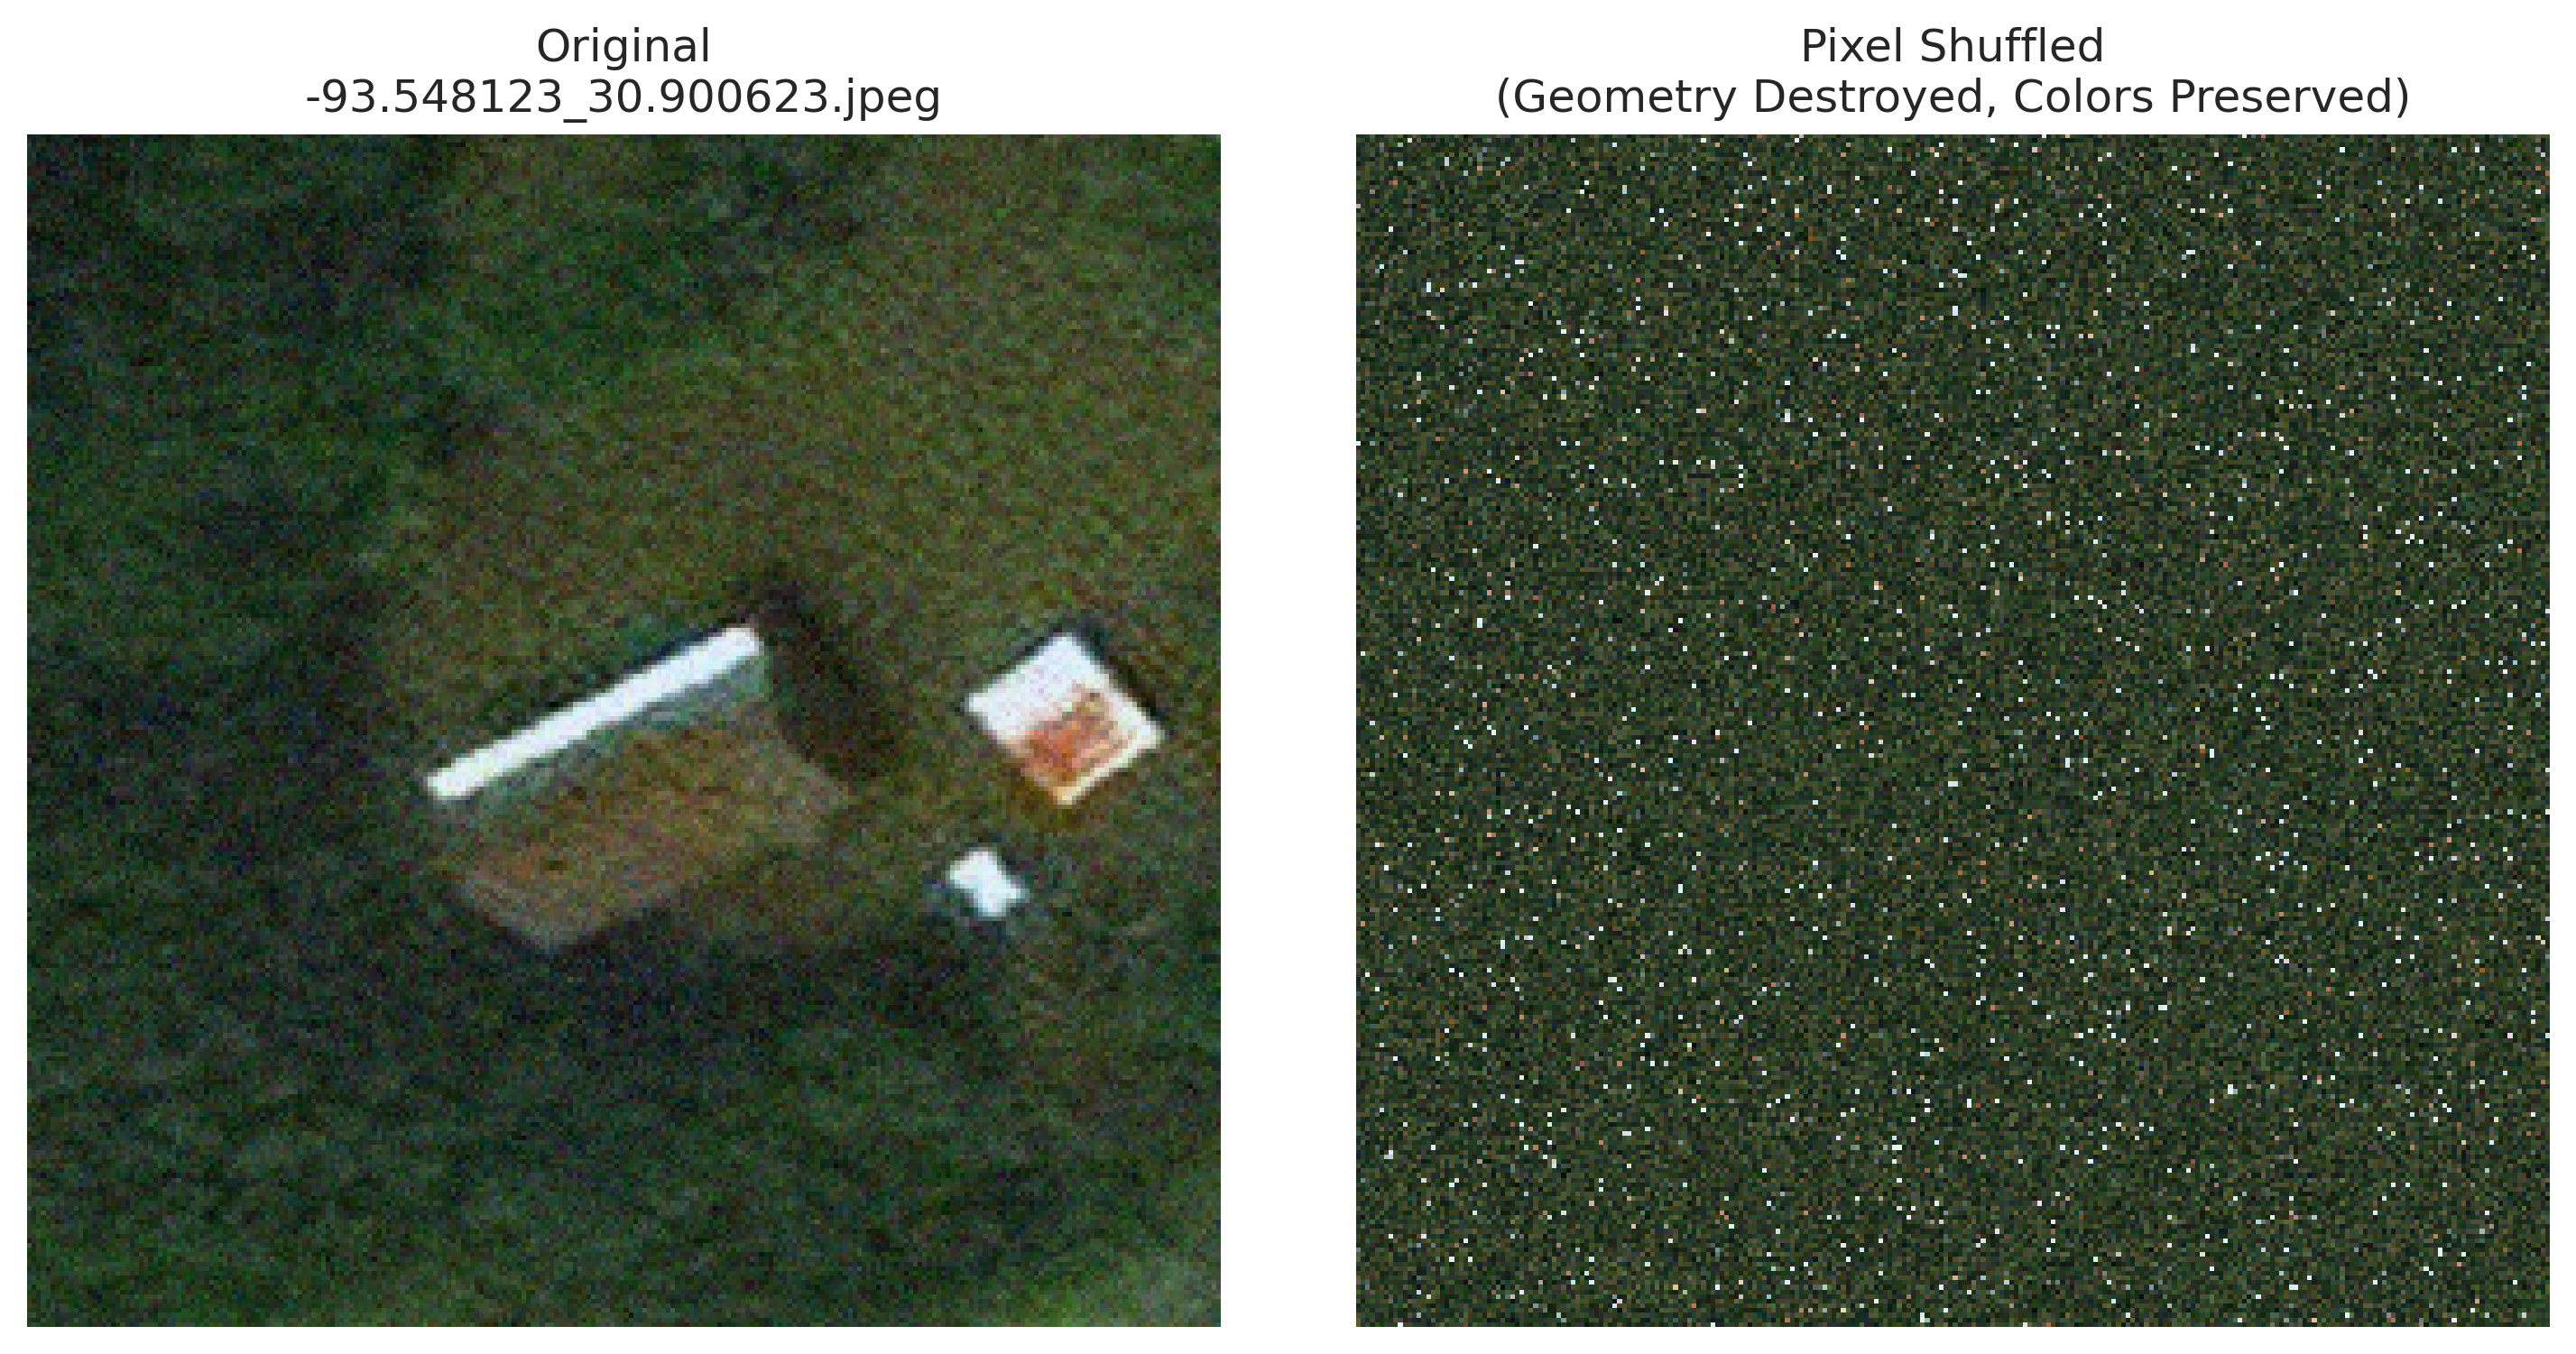

In [8]:
# Instantiate the Destroyer and load sample
destroyer = PixelShuffleDestroyer(seed=42)
samples = pick_samples(DATA_ROOT, split='test', max_samples=3)

if not samples:
    print('No samples found in test split.')
else:
    sample_path = samples[0]
    eval_tfm = make_eval_transform(base_cfg)
    img_t = load_image_tensor(sample_path, eval_tfm)  # Shape: [3, H, W]

    # Apply Pixel Shuffle as before training (Needs batch dimension [B, C, H, W])
    with torch.no_grad():
        shuffled_t = destroyer(img_t.unsqueeze(0))
        shuffled_t = shuffled_t.squeeze(0)  # Remove batch dim for plotting

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(tensor_to_numpy(img_t))
    axes[0].set_title(f"Original\n{sample_path.name}")
    axes[0].axis('off')
    axes[1].imshow(tensor_to_numpy(shuffled_t))
    axes[1].set_title("Pixel Shuffled\n(Geometry Destroyed, Colors Preserved)")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


In [19]:
shuffle_cfg = TrainConfig(
    data_root=str(DATA_ROOT),
    model_name='custom_time_detector',
    pretrained=False,
    epochs=20,
    batch_size=64,
    lr=3e-4,
    dropout=0.2,
    custom_shuffle_pixels=True,   # randomly shuffles pixels within each image (but keeps color channels aligned)
    custom_pointwise_conv=False, # swap 3x3 for 1x1 conv to destroy spatial cues
    checkpoints_dir=str(PROJECT_ROOT / 'training_runs/time_detector_shuffle/checkpoints'),
    tensorboard=True,
    wandb_mode='disabled',
    amp=False,
    early_stopping=1000,
)

In [ ]:
shuffle_trainer = Trainer(shuffle_cfg)
shuffle_train_stats = shuffle_trainer.fit()
shuffle_test_metrics = shuffle_trainer.test()
shuffle_ckpt = Path(shuffle_cfg.checkpoints_dir) / 'best.pt'
shuffle_ckpt

## Train resampled CustomTimeDetector (resampled dataset, intact pixels)


In [20]:
resampled_cfg = TrainConfig(
    data_root=str(RESAMPLED_ROOT),
    model_name='custom_time_detector',
    pretrained=False,
    epochs=20,
    batch_size=64,
    lr=3e-4,
    dropout=0.2,
    custom_shuffle_pixels=False,
    custom_pointwise_conv=False,
    checkpoints_dir=str(PROJECT_ROOT / 'training_runs/time_detector_resampled/checkpoints'),
    tensorboard=True,
    wandb_mode='disabled',
    amp=False,
    early_stopping=1000,
)

In [ ]:
resampled_trainer = Trainer(resampled_cfg)
resampled_train_stats = resampled_trainer.fit()
resampled_test_metrics = resampled_trainer.test()
resampled_ckpt = Path(resampled_cfg.checkpoints_dir) / 'best.pt'
resampled_ckpt

In [21]:
#Load all three models from their best checkpoints
base_ckpt = Path('training_runs/time_detector_base/checkpoints/') / 'best.pt'
shuffle_ckpt = Path('training_runs/time_detector_shuffle/checkpoints/') / 'best.pt'
resampled_ckpt = Path('training_runs/time_detector_resampled/checkpoints/') / 'best.pt'


## Intact post-event test (False Positive Trap)

In [30]:
# Check class mapping
dm = DataModule(base_cfg)
dm.setup()
print("Class Mapping:", dm.train_dataset.class_to_idx)


Class Mapping: {'damage': 0, 'no_damage': 1}


In [23]:
sample_image = 'data/test/damage/-95.077515_29.826657.jpeg'  # change to image path

INTACT_POST_EVENT_PATH = Path(sample_image) 
if INTACT_POST_EVENT_PATH.exists():
    eval_tfm = make_eval_transform(base_cfg)
    img_t = load_image_tensor(INTACT_POST_EVENT_PATH, eval_tfm)
    base_model = load_model_from_ckpt(base_cfg, base_ckpt)
    with torch.no_grad():
        logits = base_model(img_t.unsqueeze(0).to(DEVICE))
        probs = logits.softmax(dim=1)[0].cpu()
    print('Probabilities [damage, no_damage]:', probs.tolist())
else:
    print('Set INTACT_POST_EVENT_PATH to a real intact post-event image.')


Probabilities [damage, no_damage]: [0.37728381156921387, 0.6227161884307861]


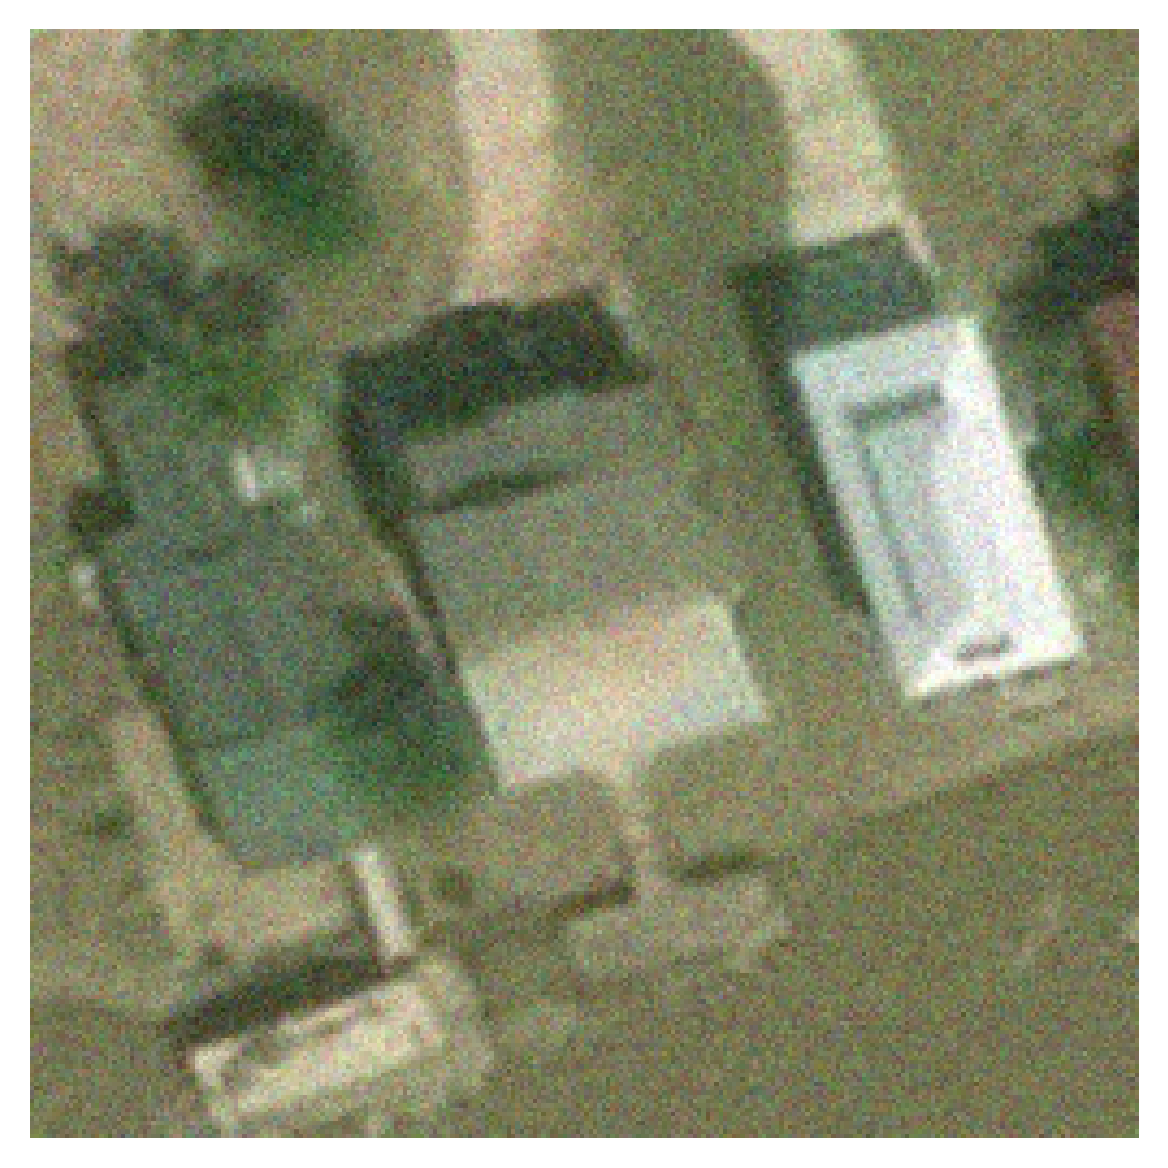

In [17]:
img = Image.open(sample_image)
plt.imshow(img)
plt.axis('off')
plt.show()


The model is 62.3% confident this building is **No Damage**.
- Ground Truth: **Damage** (Post-Event).
- Model Prediction: **No Damage** (Pre-Event)

Hypothesis:
- If it were a Structure Detector: It would see the debris/rubble and classify it as Damage, regardless of the lighting.
- Since it is a Time Detector: It relies on specific "Post-Event" global statistics (e.g., gloominess, haziness, specific sensor color calibration) to identify the positive class.
This specific image (-95.077...) likely has lighting conditions, brightness, or colors that resemble the Pre-Event (Undamaged) dataset (e.g., it might be a brighter, sunnier image than the average post-hurricane photo).

## Grad-CAM on baseline, shuffle control, and resampled model


In [38]:
# Visualize with Grad-CAM on multiple samples and save to detector_plots
eval_tfms = {
    'base': make_eval_transform(base_cfg),
    'shuffle': make_eval_transform(shuffle_cfg),
    'resampled': make_eval_transform(resampled_cfg),
}

def run_gradcams(label: str, cfg: TrainConfig, ckpt_path: Path, data_root: Path, samples: list[Path]):
    if not ckpt_path.exists():
        print(f'Skip {label}: checkpoint missing at {ckpt_path}')
        return
    model = load_model_from_ckpt(cfg, ckpt_path)
    eval_tfm = eval_tfms[label]

    print(f'{label} samples:', samples)
    for idx, sample_path in enumerate(samples):
        img_t = load_image_tensor(sample_path, eval_tfm)
        cam, probs = grad_cam_heatmap(model, img_t, class_idx=0)  # class 0 = damage
        label_name = sample_path.parent.name
        title_str = f"Label: {label_name} (Sample: {sample_path.name})\nProbability for 'Damage'-class={probs[0]:.3f}"
        fig = show_cam_on_image(img_t, cam, title=title_str)
        out_path = PLOTS_DIR / f'gradcam_{label}_{idx}.pdf'
        fig.savefig(out_path, bbox_inches='tight')
        print('Saved', out_path)
        plt.close(fig)


samples = pick_samples(DATA_ROOT, split='test', max_samples=40)

run_gradcams('base', base_cfg, base_ckpt, DATA_ROOT, samples)
run_gradcams('shuffle', shuffle_cfg, shuffle_ckpt, DATA_ROOT, samples)
run_gradcams('resampled', resampled_cfg, resampled_ckpt, RESAMPLED_ROOT, samples)

base samples: [PosixPath('/home/tim/repos/ipeo-hurricane-damage-detection/data/test/damage/-93.548123_30.900623.jpeg'), PosixPath('/home/tim/repos/ipeo-hurricane-damage-detection/data/test/damage/-93.560128_30.894917.jpeg'), PosixPath('/home/tim/repos/ipeo-hurricane-damage-detection/data/test/damage/-93.578271_30.779923999999998.jpeg'), PosixPath('/home/tim/repos/ipeo-hurricane-damage-detection/data/test/damage/-93.590598_30.694956.jpeg'), PosixPath('/home/tim/repos/ipeo-hurricane-damage-detection/data/test/damage/-93.604017_30.793719.jpeg'), PosixPath('/home/tim/repos/ipeo-hurricane-damage-detection/data/test/damage/-93.6141_30.754263.jpeg'), PosixPath('/home/tim/repos/ipeo-hurricane-damage-detection/data/test/damage/-93.618483_30.730039.jpeg'), PosixPath('/home/tim/repos/ipeo-hurricane-damage-detection/data/test/damage/-93.65613_30.076164000000002.jpeg'), PosixPath('/home/tim/repos/ipeo-hurricane-damage-detection/data/test/damage/-93.658785_30.206929.jpeg'), PosixPath('/home/tim/repo

- **Observation**: Use the three Grad-CAM grids to check whether heatmaps stay diffuse/background. Consistent background blobs across the shuffled and resampled models indicate they are still keying off global color/lighting rather than structure.

- *Interpretation*: A valid damage detector would have zero interest in empty grass. The fact that the model often activates on ground texture or roof color means it is classifying the scene (post-event atmosphere) instead of structural damage cues.

If the resampled model starts focusing on roofs/edges (while the shuffled one stays diffuse), it suggests the spatial resampling reduced some leakage; if both remain diffuse, the time-detector pathology persists.


## Training trajectories (loss + val metrics)

Plot per-epoch loss and validation macro-F1 for all three runs.


Saved /home/tim/repos/ipeo-hurricane-damage-detection/plots/01_cnn_activation_maps/training_loss_comparison.pdf


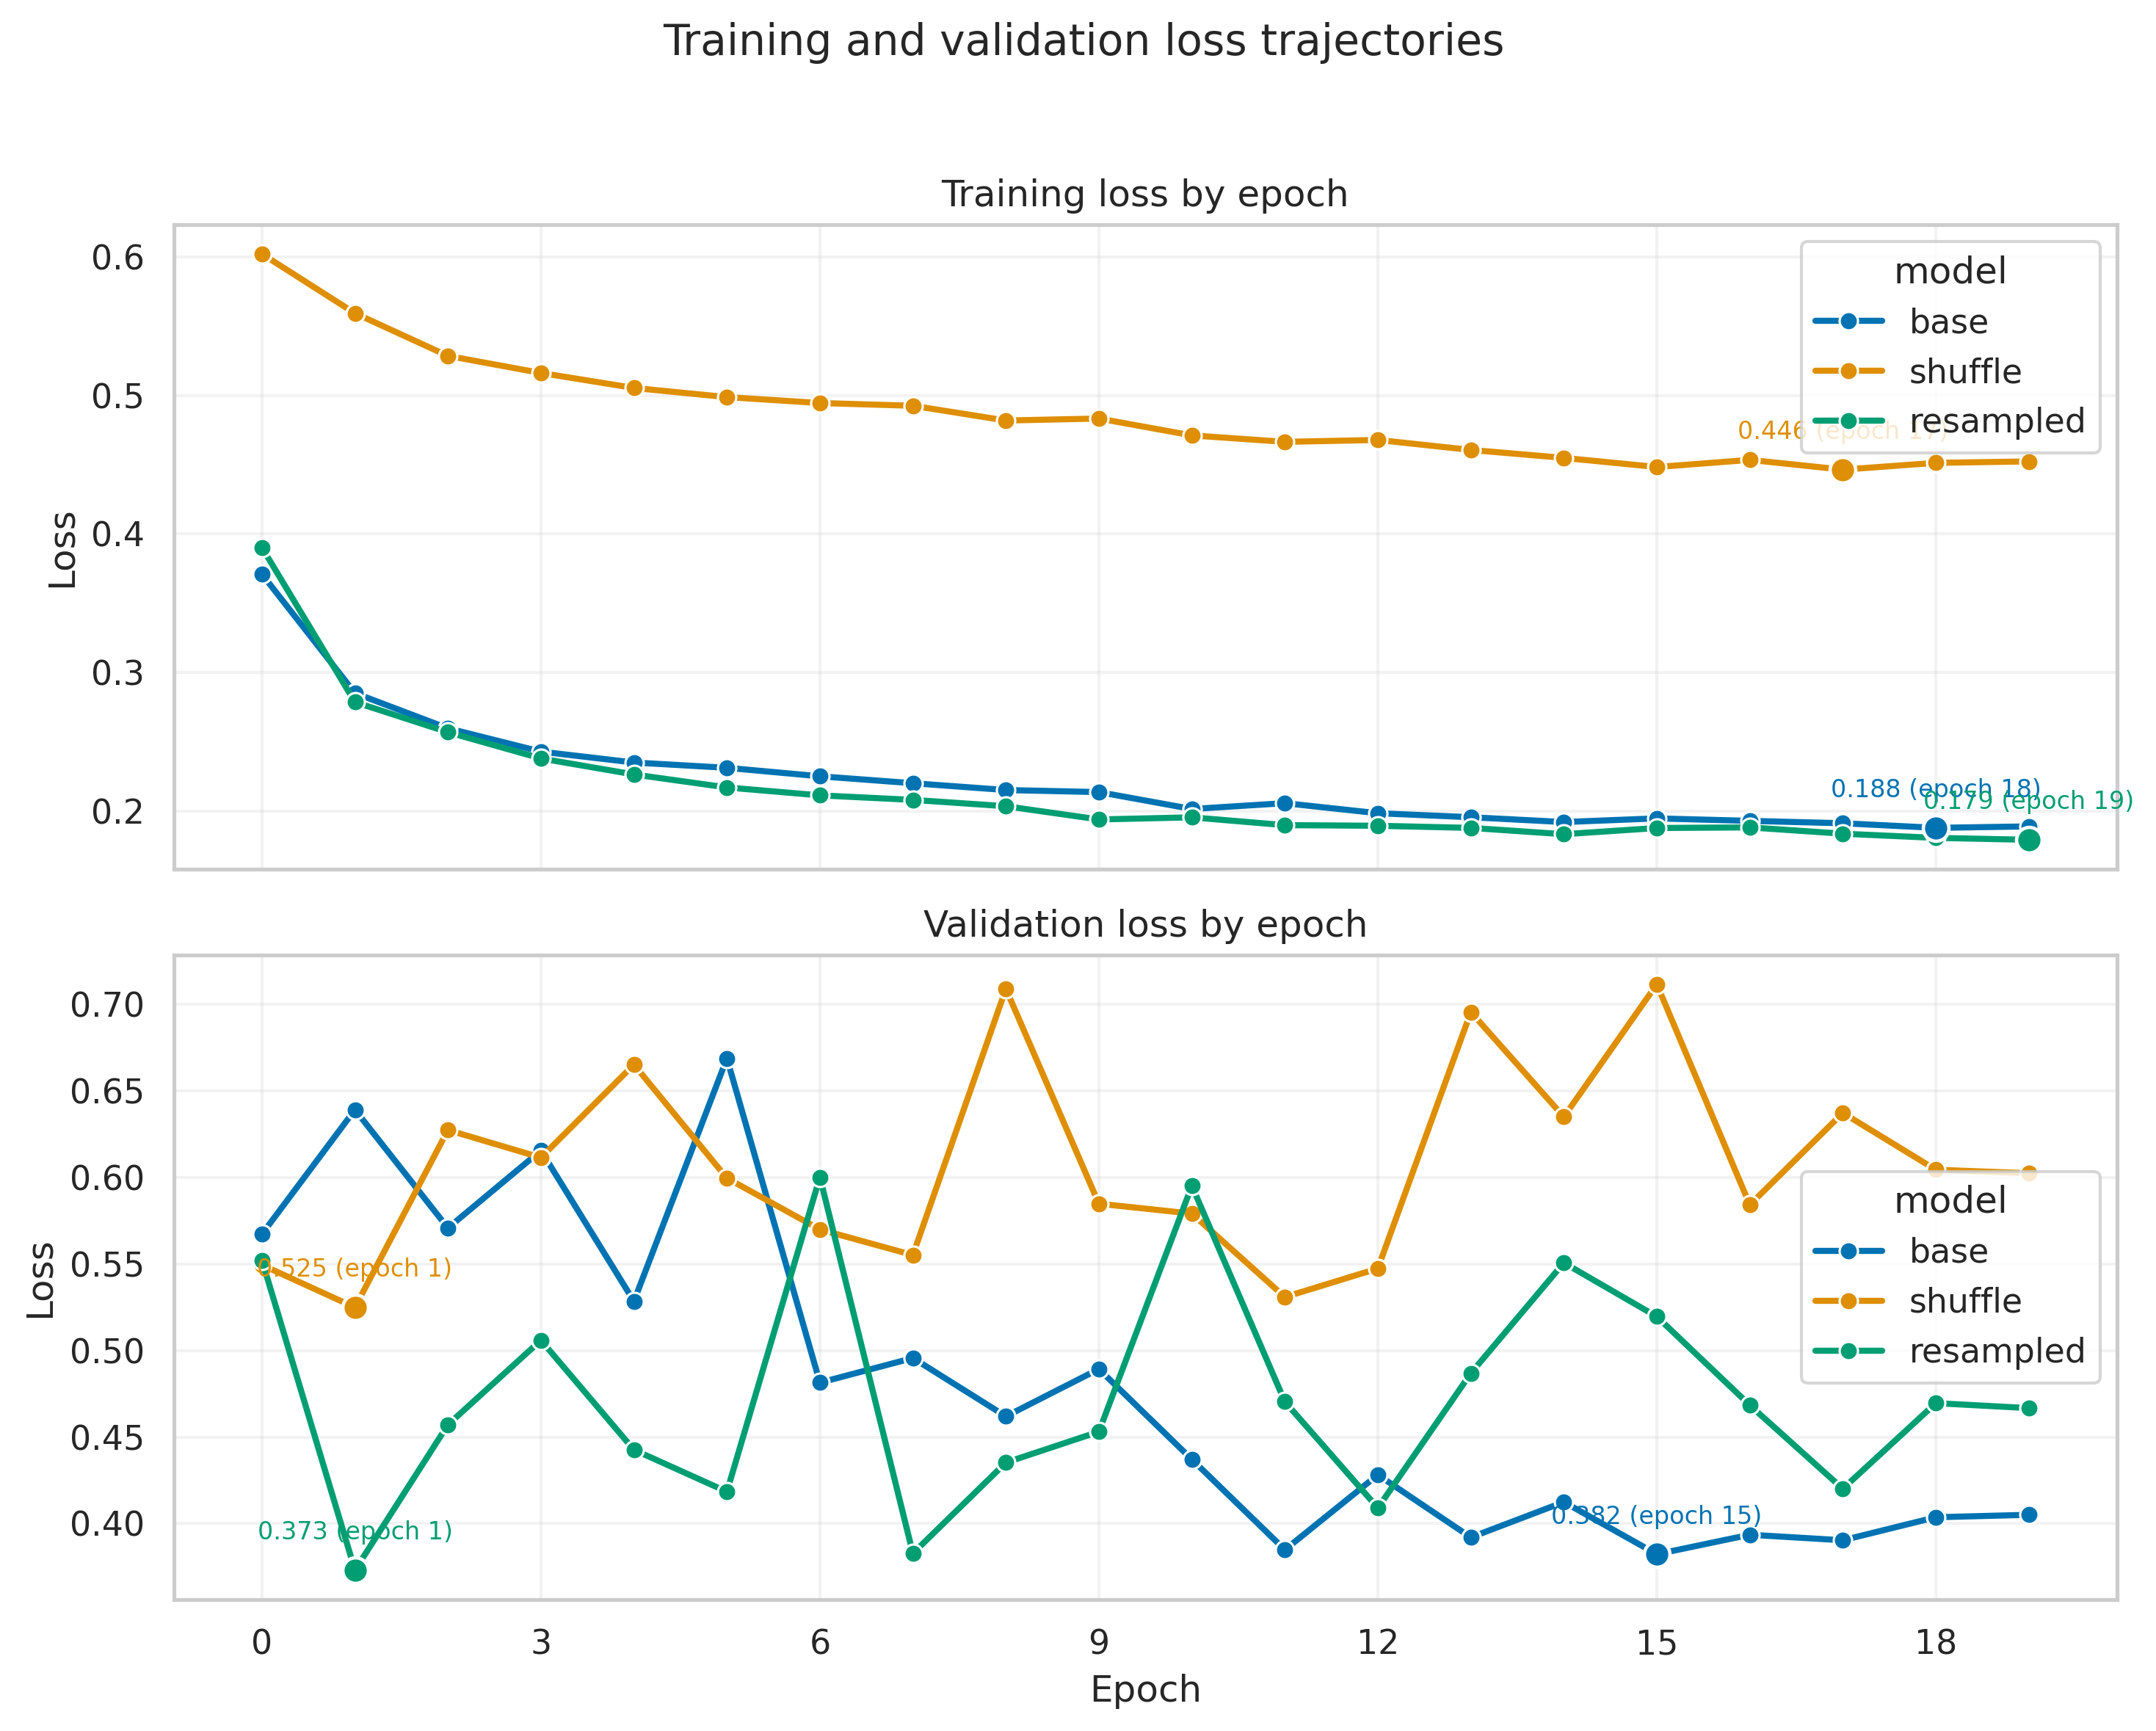

Saved /home/tim/repos/ipeo-hurricane-damage-detection/plots/01_cnn_activation_maps/validation_metrics_comparison.pdf


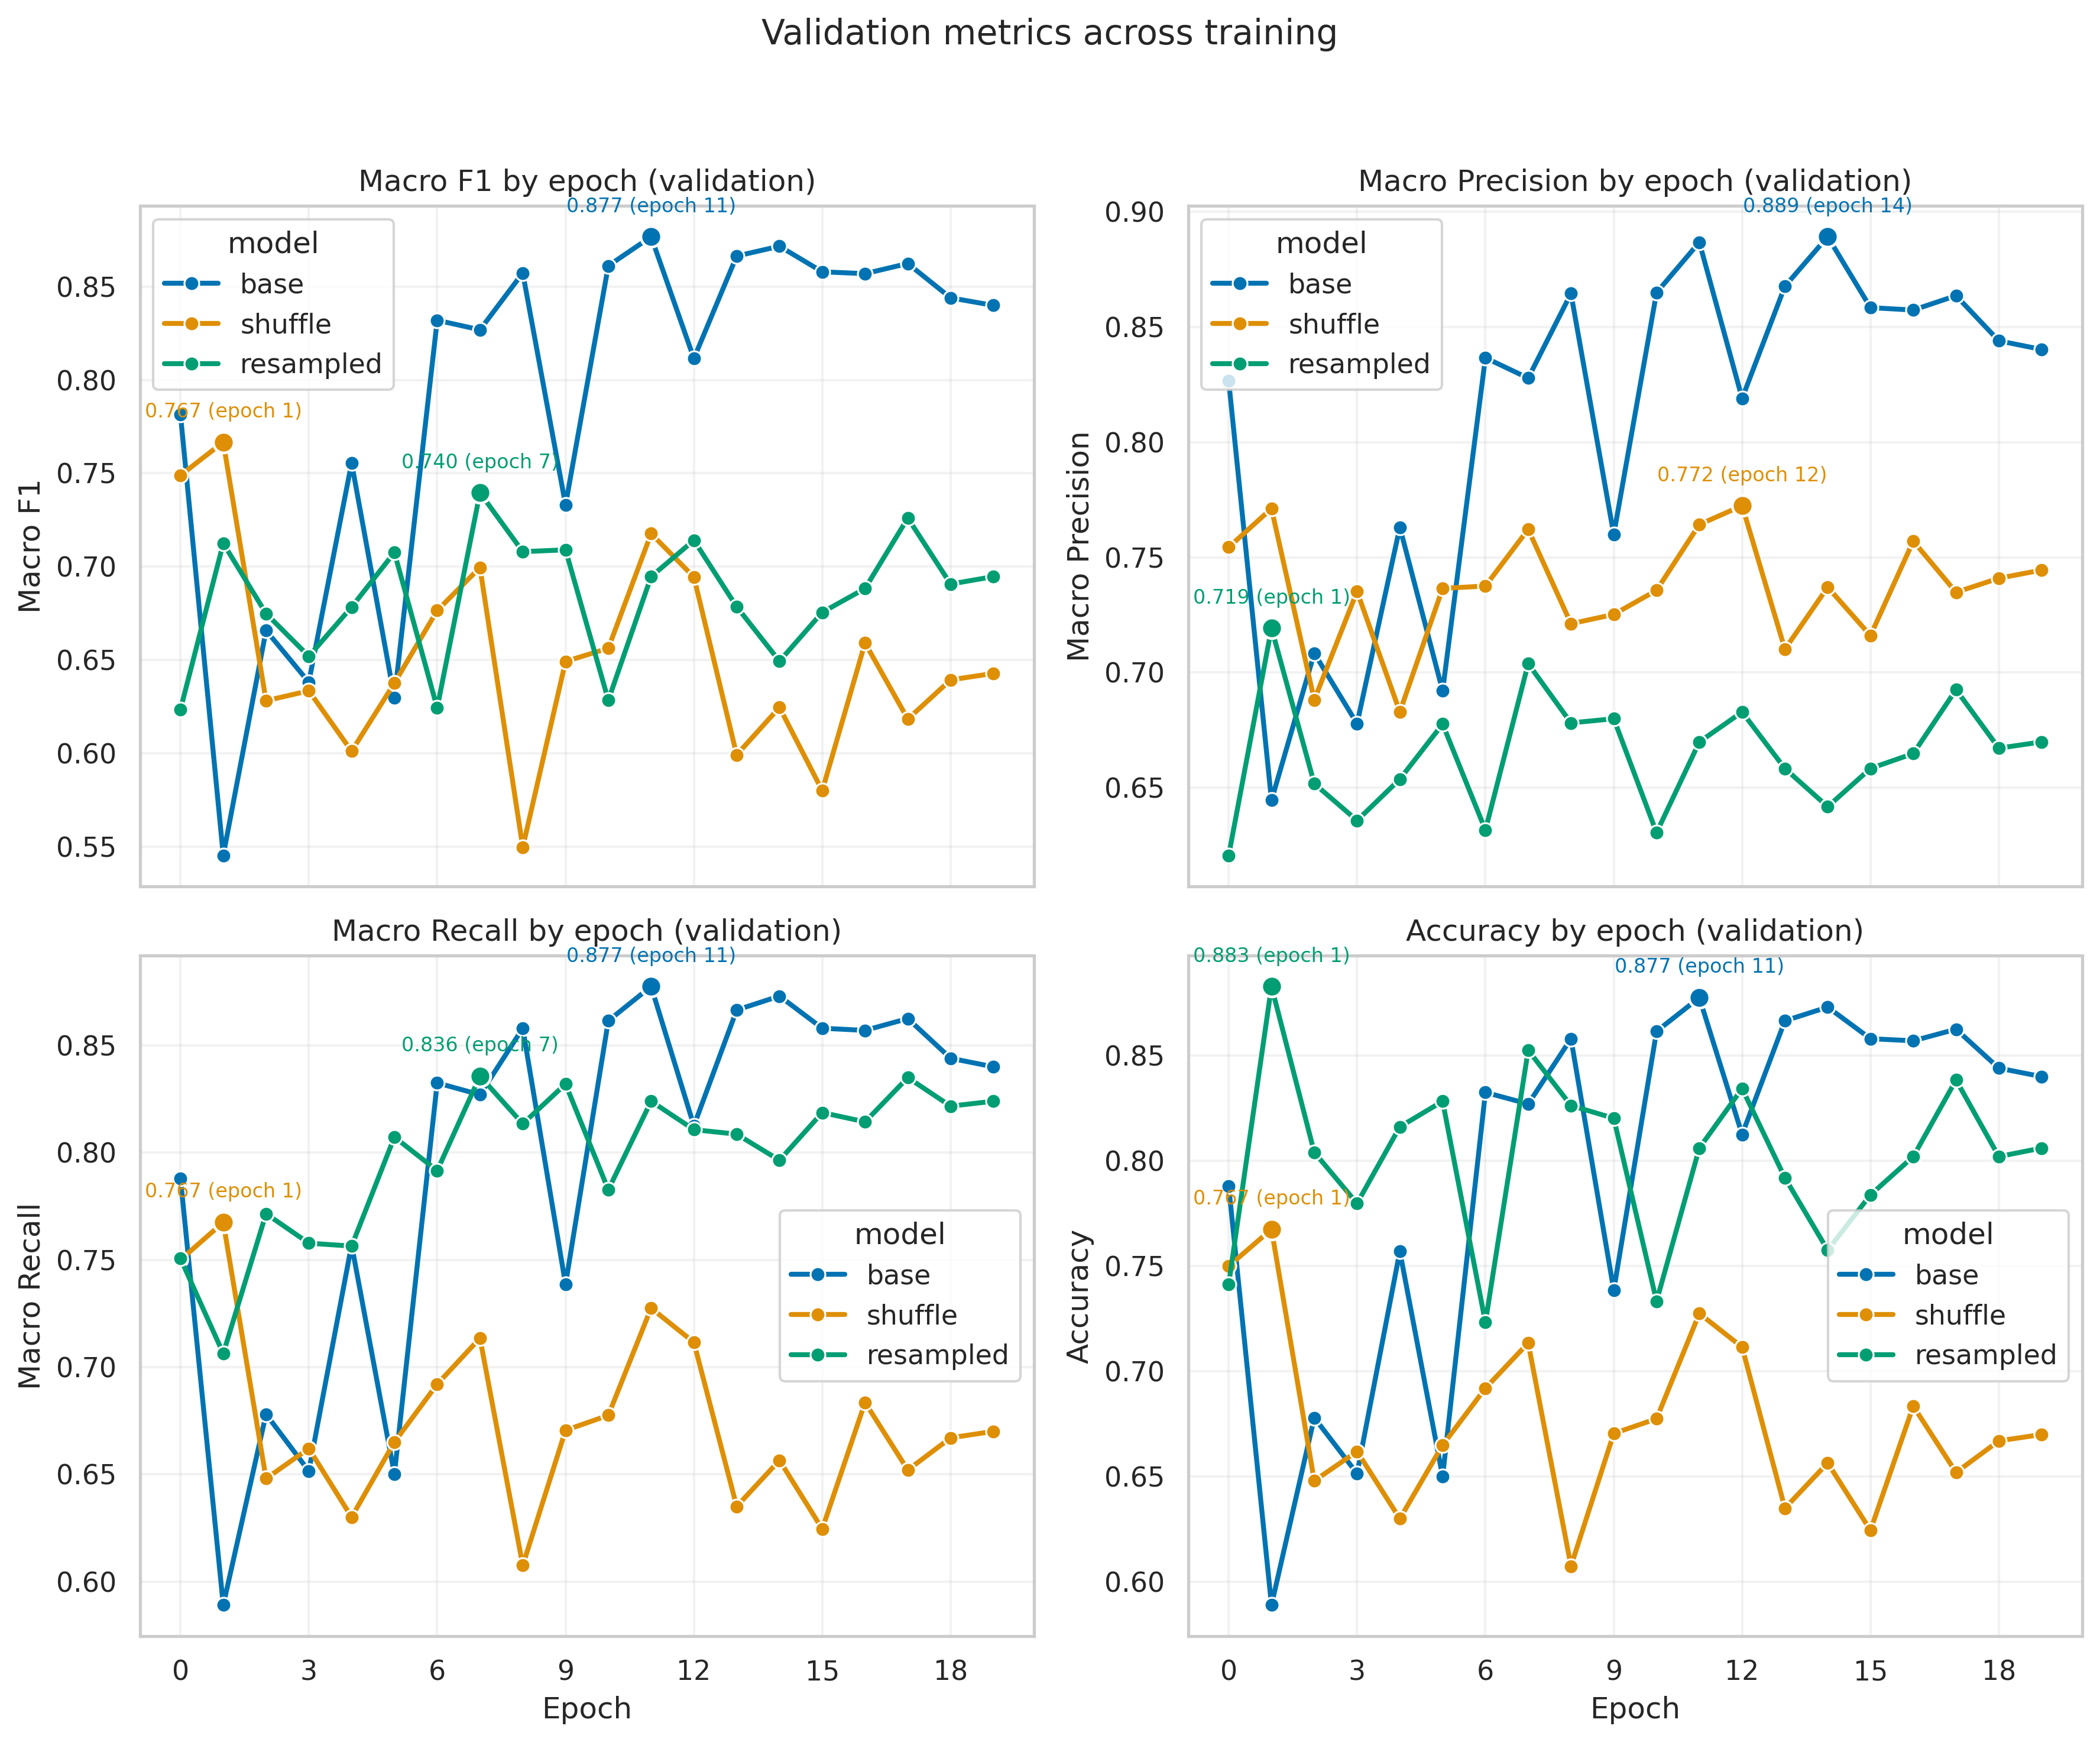

In [ ]:
sns.set_theme(style='whitegrid', palette='colorblind')


def history_frame(label: str, stats: dict):
    hist = stats.get('history', []) if stats else []
    df = pd.DataFrame(hist)
    if df.empty:
        return df
    if 'epoch' not in df.columns:
        df['epoch'] = range(len(df))
    df['model'] = label
    return df


def annotate_best(ax, data: pd.DataFrame, metric: str, palette: dict, mode: str = 'max'):
    """Highlight the best point per model for a given metric."""
    for model, group in data.groupby('model'):
        subset = group.dropna(subset=[metric])
        if subset.empty:
            continue
        idx = subset[metric].idxmin() if mode == 'min' else subset[metric].idxmax()
        best = subset.loc[idx]
        color = palette.get(model, '#333333')
        ax.scatter(best['epoch'], best[metric], color=color, s=70, edgecolor='white', linewidth=1.1, zorder=5)
        ax.annotate(
            f"{best[metric]:.3f} (epoch {int(best['epoch'])})",
            xy=(best['epoch'], best[metric]),
            xytext=(0, 10),
            textcoords='offset points',
            ha='center',
            fontsize=8,
            color=color,
        )


hist_df = pd.concat(
    [
        history_frame('base', base_train_stats),
        history_frame('shuffle', shuffle_train_stats),
        history_frame('resampled', resampled_train_stats),
    ],
    ignore_index=True,
)

if hist_df.empty:
    print('No training history available.')
else:
    hist_df = hist_df.sort_values('epoch').reset_index(drop=True)
    models = hist_df['model'].unique().tolist()
    palette = dict(zip(models, sns.color_palette('colorblind', len(models))))

    # 2x1 loss plots (train and val)
    loss_fig, loss_axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for ax, (metric, title) in zip(loss_axes, [('train_loss', 'Training loss'), ('val_loss', 'Validation loss')]):
        if metric not in hist_df.columns:
            ax.axis('off')
            ax.text(0.5, 0.5, f'{metric} not found', ha='center', va='center')
            continue
        sns.lineplot(data=hist_df, x='epoch', y=metric, hue='model', palette=palette, marker='o', linewidth=2, ax=ax)
        annotate_best(ax, hist_df[['epoch', 'model', metric]], metric, palette, mode='min')
        ax.set_title(f'{title} by epoch')
        ax.set_ylabel('Loss')
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(alpha=0.25)
    loss_axes[-1].set_xlabel('Epoch')
    loss_fig.suptitle('Training and validation loss trajectories', fontsize=14, y=0.98)
    loss_fig.tight_layout(rect=[0, 0, 1, 0.96])
    loss_out = PLOTS_DIR / 'training_loss_comparison.pdf'
    loss_fig.savefig(loss_out, bbox_inches='tight')
    print('Saved', loss_out)
    plt.show()

    # 2x2 metric plots (F1, precision, recall, accuracy)
    metric_panels = [
        ('val/macro_f1', 'Macro F1'),
        ('val/macro_precision', 'Macro Precision'),
        ('val/macro_recall', 'Macro Recall'),
        ('val/accuracy', 'Accuracy'),
    ]
    metric_fig, metric_axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
    metric_axes = metric_axes.flatten()
    any_metric = False
    for ax, (key, label) in zip(metric_axes, metric_panels):
        if key not in hist_df.columns:
            ax.axis('off')
            ax.text(0.5, 0.5, f'{label} not recorded', ha='center', va='center')
            continue
        any_metric = True
        sns.lineplot(data=hist_df, x='epoch', y=key, hue='model', palette=palette, marker='o', linewidth=2, ax=ax)
        annotate_best(ax, hist_df[['epoch', 'model', key]], key, palette, mode='max')
        ax.set_title(f'{label} by epoch (validation)')
        ax.set_ylabel(label)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(alpha=0.25)
    for ax in metric_axes[-2:]:
        ax.set_xlabel('Epoch')
    if any_metric:
        metric_fig.suptitle('Validation metrics across training', fontsize=14, y=0.98)
        metric_fig.tight_layout(rect=[0, 0, 1, 0.95])
        metrics_out = PLOTS_DIR / 'validation_metrics_comparison.pdf'
        metric_fig.savefig(metrics_out, bbox_inches='tight')
        print('Saved', metrics_out)
        plt.show()
    else:
        plt.close(metric_fig)
        print('No validation metrics to plot.')


## Compare performance: baseline vs shuffled vs resampled


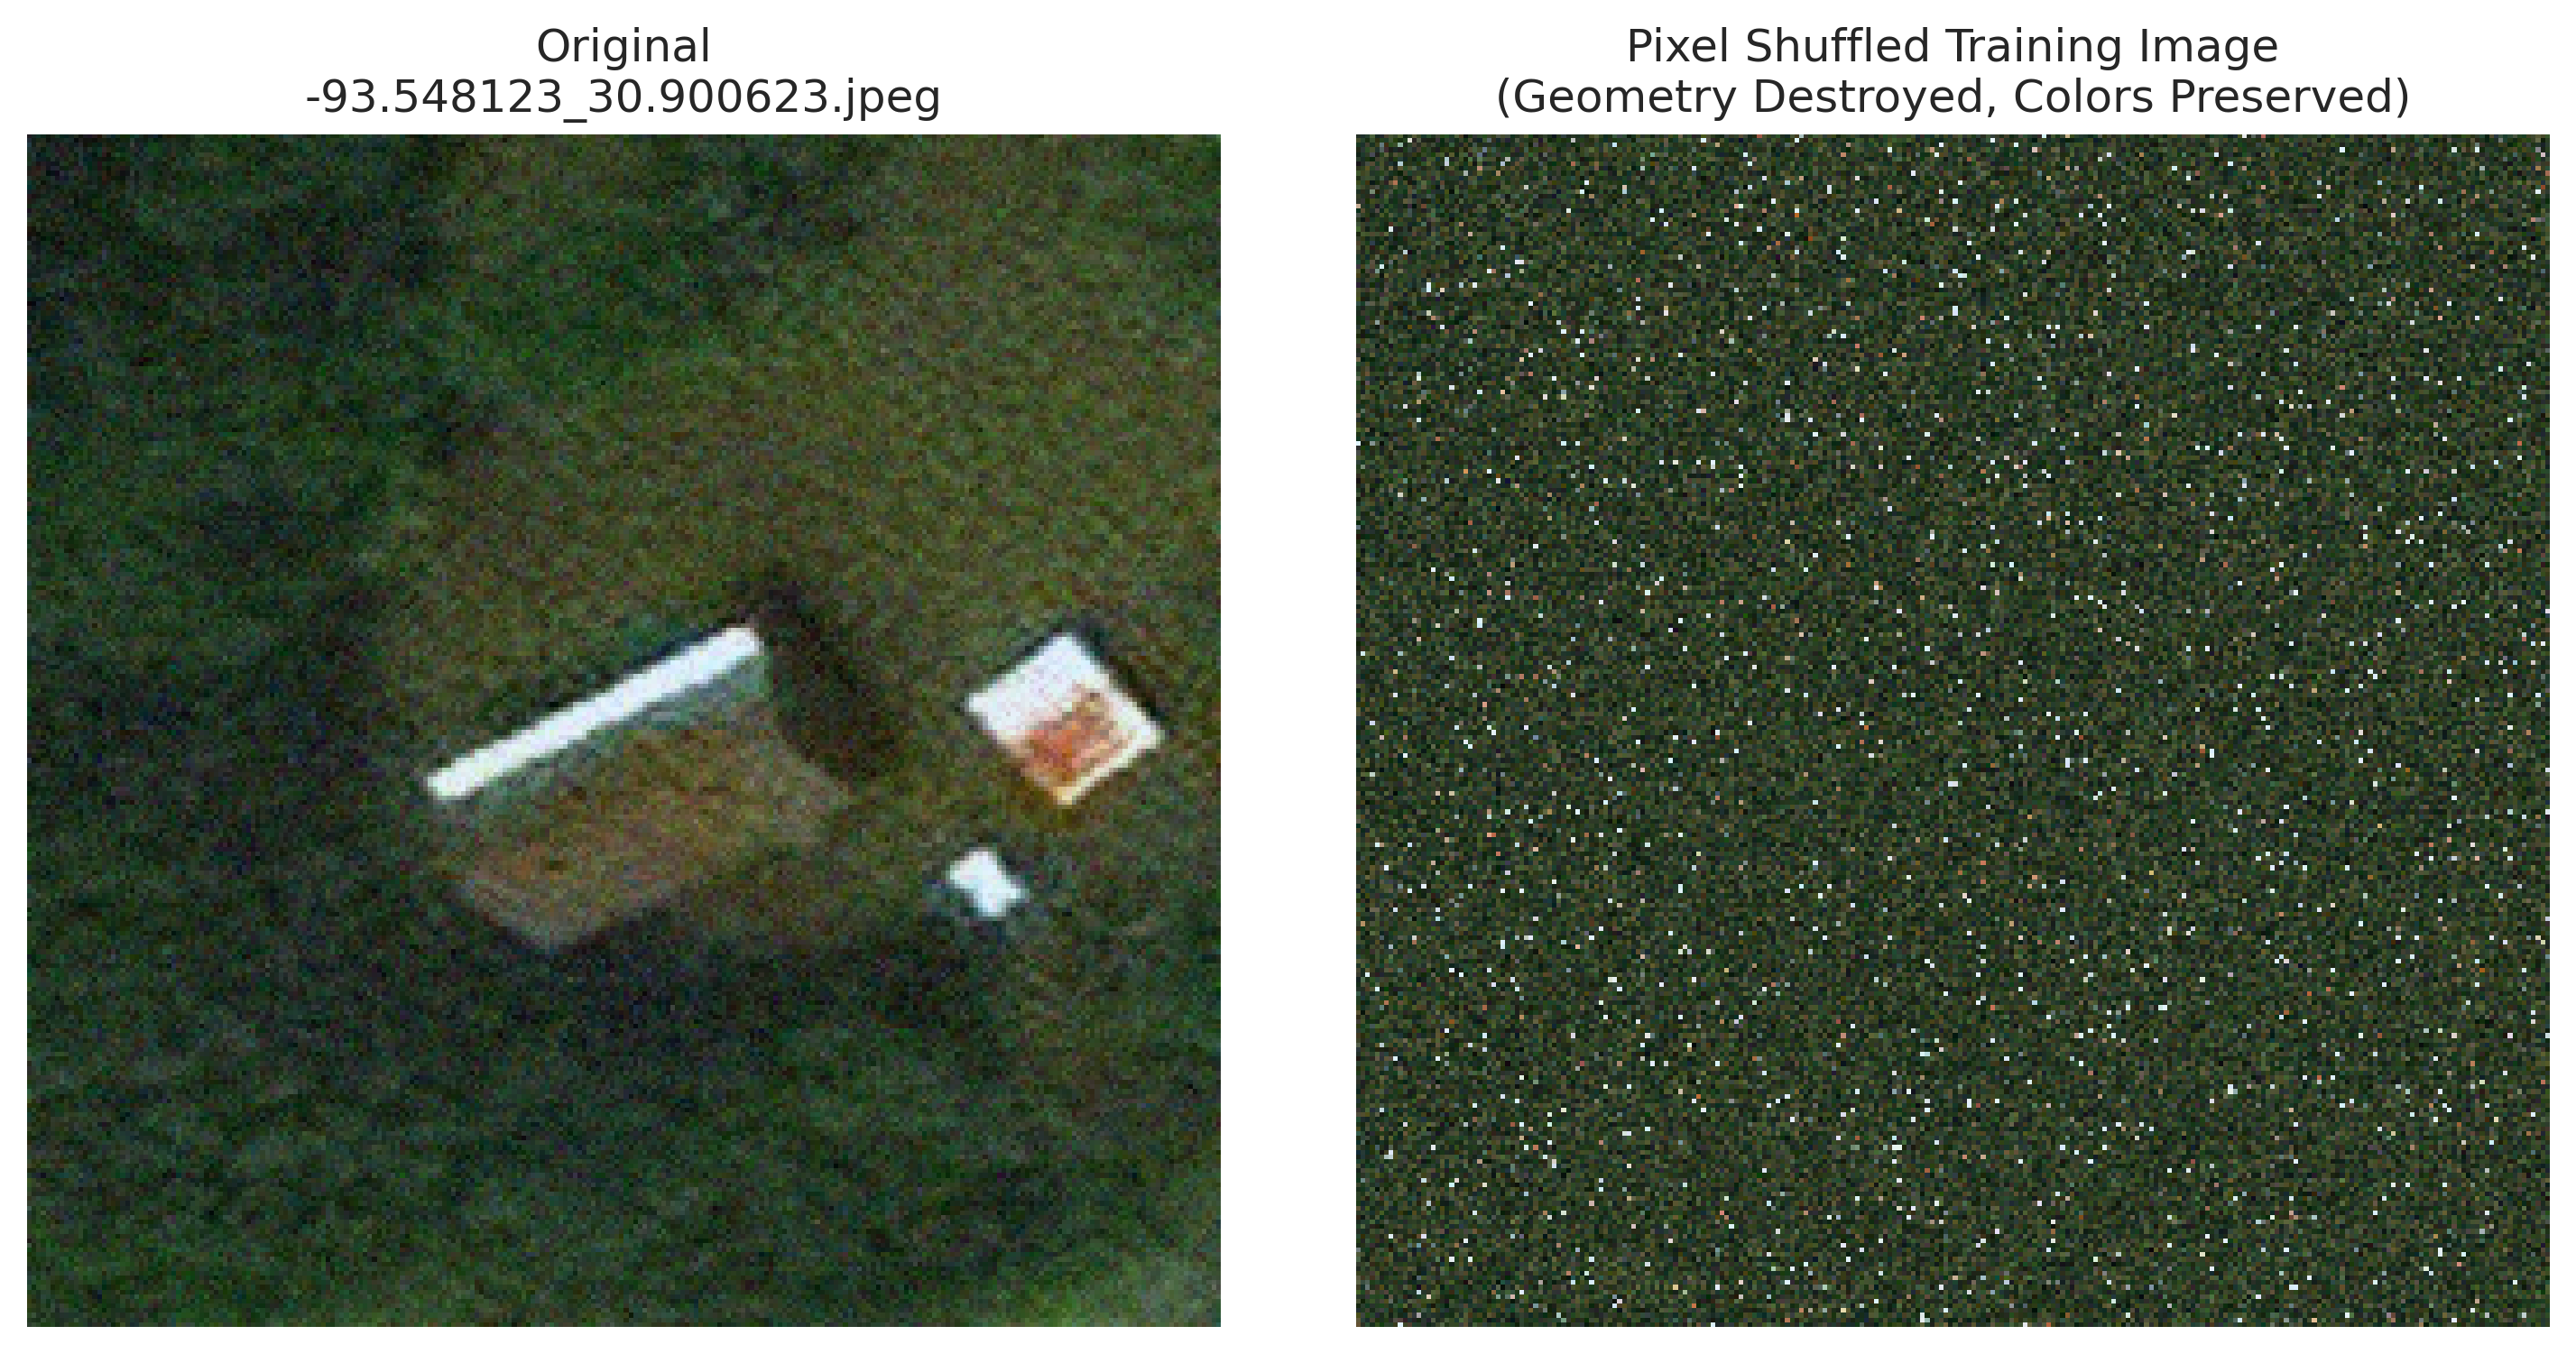

In [26]:
destroyer = PixelShuffleDestroyer(seed=42)

eval_tfm = eval_tfms.get('base', make_eval_transform(base_cfg))
samples = pick_samples(DATA_ROOT, split='test', max_samples=5)

if not samples:
    print('No test samples found for pixel shuffle demo.')
else:
    sample_path = samples[0]
    img_t = load_image_tensor(sample_path, eval_tfm)  # Shape: [3, H, W]

    # Apply Shuffle (Needs batch dimension [B, C, H, W])
    with torch.no_grad():
        shuffled_t = destroyer(img_t.unsqueeze(0))
        shuffled_t = shuffled_t.squeeze(0)  # Remove batch dim for plotting

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(tensor_to_numpy(img_t))
    axes[0].set_title(f"Original\n{sample_path.name}")
    axes[0].axis('off')

    axes[1].imshow(tensor_to_numpy(shuffled_t))
    axes[1].set_title("Pixel Shuffled Training Image\n(Geometry Destroyed, Colors Preserved)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


In [27]:
print('Baseline test metrics:', base_test_metrics)
print('Shuffled test metrics:', shuffle_test_metrics)
print('Resampled test metrics:', resampled_test_metrics)


NameError: name 'base_test_metrics' is not defined

In [28]:
# comparison of metrics and logit biases

sns.set_theme(style='whitegrid', palette='colorblind')

metrics_df = pd.DataFrame([
    {'model': 'base', **base_test_metrics},
    {'model': 'shuffle', **shuffle_test_metrics},
    {'model': 'resampled', **resampled_test_metrics},
])
best_epochs = {
    'base': base_train_stats.get('best_epoch') if isinstance(base_train_stats, dict) else None,
    'shuffle': shuffle_train_stats.get('best_epoch') if isinstance(shuffle_train_stats, dict) else None,
    'resampled': resampled_train_stats.get('best_epoch') if isinstance(resampled_train_stats, dict) else None,
}

if not metrics_df.empty:
    palette = dict(zip(metrics_df['model'], sns.color_palette('colorblind', metrics_df['model'].nunique())))
    melted = metrics_df.melt(id_vars='model', var_name='metric', value_name='score')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.barplot(data=melted, x='metric', y='score', hue='model', palette=palette, ax=axes[0])
    axes[0].set_title('Test metrics across models')
    axes[0].set_ylabel('Score')
    axes[0].set_xlabel('Metric')
    axes[0].tick_params(axis='x', rotation=35)
    axes[0].grid(axis='y', alpha=0.25)
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.3f', padding=3, fontsize=8)

    focus_cols = [c for c in ['accuracy', 'macro_f1', 'macro_precision', 'macro_recall'] if c in metrics_df.columns]
    if focus_cols:
        focus_df = metrics_df[['model'] + focus_cols].melt(id_vars='model', var_name='metric', value_name='score')
        sns.barplot(data=focus_df, x='metric', y='score', hue='model', palette=palette, ax=axes[1])
        axes[1].set_title('Key metrics (higher is better)')
        axes[1].set_ylabel('Score')
        axes[1].set_xlabel('Metric')
        axes[1].tick_params(axis='x', rotation=0)
        axes[1].grid(axis='y', alpha=0.25)
        for container in axes[1].containers:
            axes[1].bar_label(container, fmt='%.3f', padding=3, fontsize=8)
    else:
        axes[1].axis('off')
        axes[1].text(0.5, 0.5, 'No key metrics available', ha='center', va='center')

    best_epoch_line = ' | '.join(
        f"{model}: epoch {epoch if isinstance(epoch, (int, float)) and epoch >= 0 else 'n/a'}"
        for model, epoch in best_epochs.items()
    )
    fig.suptitle('Test metrics and best validation epochs', fontsize=14, y=0.98)
    fig.text(0.5, 0.02, f'Best validation epoch per model → {best_epoch_line}', ha='center', fontsize=10)
    fig.tight_layout(rect=[0, 0.05, 1, 0.94])

    out_path = PLOTS_DIR / 'metrics_comparison.pdf'
    fig.savefig(out_path, bbox_inches='tight')
    print('Saved', out_path)
    plt.show()
else:
    print('No metrics to plot.')


NameError: name 'base_test_metrics' is not defined

- **Observation**: The pixel-shuffled control (orange) staying strong highlights reliance on color/statistics over structure. The resampled run (green) should ideally drop toward chance if resampling removed the leakage; if it tracks the others, the time-detector bias remains.

- *Implication*: A valid damage detector relies on structural features like holes in roofs, debris piles, or jagged edges. If pixels are shuffled, these features disappear, and a structural model's accuracy should drop to random guessing (~50%).

- **Conclusion**: Comparing all three runs (raw, shuffled, resampled) clarifies whether spatial resampling mitigates the domain leakage or if the model continues to exploit global color cues.


## Experiment Conclusions

Why the models trained on the original dataset do not learn anything about damage:

| Experiment | Input Image | Model Prediction | Why? (Hypothesis) |
| :--- | :--- | :--- | :--- |
| **Pixel Shuffle** | **Noise (No Structure)** | **Damage** (High Conf) | The color histogram matches the "Post-Event" domain. |
| **Grad-CAM** | **Damaged Building** | **Focus on grass etc.** | The model detects the "Post-Event" texture of the ground, not the building. |
| **False Negative** | **Damaged Building** | **No Damage** (62% Conf) | The lighting/atmosphere of this specific image likely mimics the "Pre-Event" domain, fooling the time detector. |